In [25]:
!nvidia-smi

Sat Jan 10 03:12:22 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   68C    P0             30W /   70W |    2204MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!pip install opendatasets

In [ ]:
import opendatasets as od
od.download("https://www.kaggle.com/datasets/samithsachidanandan/human-face-emotions")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: ditheswarsabbu
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/samithsachidanandan/human-face-emotions


100%|██████████| 701M/701M [00:11<00:00, 66.3MB/s]


In [ ]:
import os
import cv2
import numpy as np
import warnings
warnings.filterwarnings("ignore")

# ================= CONFIG ================= #
DATASET_DIR = r"D:\se\old_ everything\data-change\archive\Data"   # <-- CHANGE THIS
OUTPUT_DIR = r"D:\se\old_ everything\final model changed all\processed dataset"  # <-- NEW: output directory
IMG_SIZE = 48

EMOTIONS = {
    "Angry": 0,
    "Fear": 1,
    "Happy": 2,
    "Sad": 3,
    "Suprise": 4
}
# ========================================= #

# Create output directory if it doesn't exist
os.makedirs(OUTPUT_DIR, exist_ok=True)

X = []
y = []

print("[INFO] Starting preprocessing...")

for emotion, label in EMOTIONS.items():
    emotion_dir = os.path.join(DATASET_DIR, emotion)

    if not os.path.exists(emotion_dir):
        print(f"[WARNING] Folder missing: {emotion_dir}")
        continue

    for img_name in os.listdir(emotion_dir):
        img_path = os.path.join(emotion_dir, img_name)

        try:
            img = cv2.imread(img_path)

            if img is None:
                continue

            # Convert to grayscale if needed
            if len(img.shape) == 3:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

            # Resize
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

            # Normalize
            img = img.astype("float32") / 255.0

            X.append(img)
            y.append(label)

        except Exception:
            continue

X = np.array(X)
X = np.expand_dims(X, axis=-1)

# One-hot encoding
num_classes = len(EMOTIONS)
y = np.array(y)
y_onehot = np.zeros((len(y), num_classes), dtype=np.float32)
y_onehot[np.arange(len(y)), y] = 1.0

# Save in separate directory
x_path = os.path.join(OUTPUT_DIR, "fdataX.npy")
y_path = os.path.join(OUTPUT_DIR, "flabels.npy")

np.save(x_path, X)
np.save(y_path, y_onehot)

print("\n[INFO] Preprocessing completed")
print("[INFO] Total samples:", len(X))
print("[INFO] X shape:", X.shape)
print("[INFO] y shape:", y_onehot.shape)
print("[INFO] Saved files:")
print("       ", x_path)
print("       ", y_path)


[INFO] Starting preprocessing...

[INFO] Preprocessing completed
[INFO] Total samples: 59099
[INFO] X shape: (59099, 48, 48, 1)
[INFO] y shape: (59099, 5)
[INFO] Saved files:
        /content/processed_data/fdataX.npy
        /content/processed_data/flabels.npy


In [4]:
!rm -rf /content/results
!rm -rf /content/processed_data


In [6]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
    roc_curve,
    auc
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, BatchNormalization,
    Dense, Dropout, Flatten
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import categorical_crossentropy
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.utils import to_categorical

from itertools import cycle

# ================= CONFIG =================
NUM_CLASSES = 5
CLASS_NAMES = ['Angry', 'Fear', 'Happy', 'Sad', 'Suprise']
IMG_SIZE = 48
BATCH_SIZE = 64
EPOCHS = 100
LEARNING_RATE = 1e-3

DATA_DIR = r"/content/processed_data"
MODEL_DIR = r"/content/model"
RESULTS_DIR = r"/content/results"

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

plt.style.use("seaborn-v0_8-paper")
sns.set_palette("husl")

# =========================================
print("[INFO] Loading data...")
X = np.load(os.path.join(DATA_DIR, "fdataX.npy"))
y = np.load(os.path.join(DATA_DIR, "flabels.npy"))

print("[INFO] Dataset shape:", X.shape, y.shape)

# -----------------------------------------
# Stratification fix (CORRECT)
# -----------------------------------------
y_labels = np.argmax(y, axis=1)

X_train, X_test, y_train, y_test, y_train_lbl, _ = train_test_split(
    X, y, y_labels,
    test_size=0.15,
    random_state=42,
    stratify=y_labels
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train,
    test_size=0.15,
    random_state=42,
    stratify=y_train_lbl
)

print(f"[INFO] Train: {X_train.shape}")
print(f"[INFO] Val  : {X_val.shape}")
print(f"[INFO] Test : {X_test.shape}")

# -----------------------------------------
# FERNet Architecture (UNCHANGED)
# -----------------------------------------
model = Sequential([
    Conv2D(64, (3, 3), activation="relu", input_shape=(IMG_SIZE, IMG_SIZE, 1)),
    BatchNormalization(),
    Conv2D(64, (3, 3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.3),

    Conv2D(128, (3, 3), activation="relu", padding="same"),
    BatchNormalization(),
    Conv2D(128, (3, 3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.4),

    Conv2D(256, (3, 3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.4),

    Flatten(),
    Dense(256, activation="relu"),
    Dropout(0.5),
    Dense(NUM_CLASSES, activation="softmax")
])

model.summary()

# -----------------------------------------
# Compile
# -----------------------------------------
model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss=categorical_crossentropy,
    metrics=["accuracy"]
)

# -----------------------------------------
# Callbacks (BEST .keras + .h5)
# -----------------------------------------
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=os.path.join(MODEL_DIR, "fernet_best.keras"),
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=os.path.join(MODEL_DIR, "fernet_best.h5"),
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

# -----------------------------------------
# Training
# -----------------------------------------
print("\n[INFO] Training started...")
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    callbacks=callbacks,
    verbose=1
)

# -----------------------------------------
# HISTORY → CSV (IMPORTANT)
# -----------------------------------------
history_df = pd.DataFrame(history.history)
history_csv = os.path.join(RESULTS_DIR, "training_history.csv")
history_df.to_csv(history_csv, index=False)
print(f"[SAVED] Training history CSV → {history_csv}")

# -----------------------------------------
# Best Epoch Reporting
# -----------------------------------------
best_epoch = np.argmin(history.history["val_loss"]) + 1
best_val_loss = np.min(history.history["val_loss"])
best_val_acc = history.history["val_accuracy"][best_epoch - 1]

print("\n" + "="*60)
print("BEST EPOCH SUMMARY")
print("="*60)
print(f"Best Epoch        : {best_epoch}")
print(f"Best Val Loss     : {best_val_loss:.4f}")
print(f"Best Val Accuracy : {best_val_acc:.4f}")
print("="*60 + "\n")

# -----------------------------------------
# Epoch-wise visibility (FINAL LOG)
# -----------------------------------------
print("Epoch-wise Metrics:")
for i in range(len(history.history["loss"])):
    print(
        f"Epoch {i+1:03d} | "
        f"Loss: {history.history['loss'][i]:.4f} | "
        f"Acc: {history.history['accuracy'][i]:.4f} | "
        f"Val Loss: {history.history['val_loss'][i]:.4f} | "
        f"Val Acc: {history.history['val_accuracy'][i]:.4f}"
    )

# -----------------------------------------
# Combined Accuracy & Loss Plot
# -----------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
ax[0].plot(history.history["accuracy"], label="Train Acc")
ax[0].plot(history.history["val_accuracy"], label="Val Acc")
ax[0].set_title("Training vs Validation Accuracy")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Accuracy")
ax[0].legend()
ax[0].grid(alpha=0.3)

# Loss
ax[1].plot(history.history["loss"], label="Train Loss")
ax[1].plot(history.history["val_loss"], label="Val Loss")
ax[1].set_title("Training vs Validation Loss")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Loss")
ax[1].legend()
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "loss_accuracy_combined.png"), dpi=300)
plt.close()

# -----------------------------------------
# Save Final Models
# -----------------------------------------
model.save(os.path.join(MODEL_DIR, "fernet_final.keras"))
model.save(os.path.join(MODEL_DIR, "fernet_final.h5"))

print("\n[INFO] Training COMPLETE")
print("[INFO] Best model saved as:")
print("   → fernet_best.keras")
print("   → fernet_best.h5")
print("[INFO] Final model saved as:")
print("   → fernet_final.keras")
print("   → fernet_final.h5")
print("[INFO] Results saved in:", RESULTS_DIR)


[INFO] Loading data...
[INFO] Dataset shape: (59099, 48, 48, 1) (59099, 5)
[INFO] Train: (42698, 48, 48, 1)
[INFO] Val  : (7536, 48, 48, 1)
[INFO] Test : (8865, 48, 48, 1)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 46, 46, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 46, 46, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 46, 46, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 46, 46, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 23, 23, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 23, 23, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 23, 23, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 23, 23, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 11, 11, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 11, 11, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 11, 11, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 11, 11, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     1,638,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,196,677 (8.38 MB)

 Trainable params: 2,195,397 (8.37 MB)

...

668/668 ━━━━━━━━━━━━━━━━━━━━ 21s 31ms/step - accuracy: 0.8510 - loss: 0.3903 - val_accuracy: 0.8591 - val_loss: 0.4712
Epoch 52/100
667/668 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.8597 - loss: 0.3832
Epoch 52: val_loss did not improve from 0.47118

Epoch 52: val_loss did not improve from 0.47118
668/668 ━━━━━━━━━━━━━━━━━━━━ 20s 31ms/step - accuracy: 0.8597 - loss: 0.3832 - val_accuracy: 0.8473 - val_loss: 0.4783
Epoch 53/100
667/668 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.8592 - loss: 0.3781
Epoch 53: val_loss did not improve from 0.47118

Epoch 53: val_loss did not improve from 0.47118
668/668 ━━━━━━━━━━━━━━━━━━━━ 20s 31ms/step - accuracy: 0.8592 - loss: 0.3781 - val_accuracy: 0.8551 - val_loss: 0.4778
Epoch 54/100
667/668 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.8584 - loss: 0.3838
Epoch 54: val_loss did not improve from 0.47118

Epoch 54: val_loss did not improve from 0.47118
668/668 ━━━━━━━━━━━━━━━━━━━━ 20s 31ms/step - accuracy: 0.8584 - loss: 0.3838 - val_ac

668/668 ━━━━━━━━━━━━━━━━━━━━ 21s 31ms/step - accuracy: 0.8669 - loss: 0.3599 - val_accuracy: 0.8681 - val_loss: 0.4598
Epoch 60/100
667/668 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.8727 - loss: 0.3438
Epoch 60: val_loss improved from 0.45984 to 0.44561, saving model to /content/model/fernet_best.keras

Epoch 60: val_loss improved from 0.45984 to 0.44561, saving model to /content/model/fernet_best.h5


668/668 ━━━━━━━━━━━━━━━━━━━━ 21s 31ms/step - accuracy: 0.8726 - loss: 0.3439 - val_accuracy: 0.8725 - val_loss: 0.4456
Epoch 61/100
667/668 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.8704 - loss: 0.3532
Epoch 61: val_loss did not improve from 0.44561

Epoch 61: val_loss did not improve from 0.44561
668/668 ━━━━━━━━━━━━━━━━━━━━ 20s 31ms/step - accuracy: 0.8704 - loss: 0.3532 - val_accuracy: 0.8635 - val_loss: 0.4612
Epoch 62/100
667/668 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.8807 - loss: 0.3289
Epoch 62: val_loss did not improve from 0.44561

Epoch 62: val_loss did not improve from 0.44561
668/668 ━━━━━━━━━━━━━━━━━━━━ 21s 31ms/step - accuracy: 0.8807 - loss: 0.3289 - val_accuracy: 0.8767 - val_loss: 0.4601
Epoch 63/100
667/668 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.8741 - loss: 0.3363
Epoch 63: val_loss did not improve from 0.44561

Epoch 63: val_loss did not improve from 0.44561
668/668 ━━━━━━━━━━━━━━━━━━━━ 21s 31ms/step - accuracy: 0.8741 - loss: 0.3363 - val_ac

668/668 ━━━━━━━━━━━━━━━━━━━━ 21s 31ms/step - accuracy: 0.8817 - loss: 0.3315 - val_accuracy: 0.8777 - val_loss: 0.4318
Epoch 66/100
667/668 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.8814 - loss: 0.3182
Epoch 66: val_loss did not improve from 0.43183

Epoch 66: val_loss did not improve from 0.43183
668/668 ━━━━━━━━━━━━━━━━━━━━ 21s 31ms/step - accuracy: 0.8813 - loss: 0.3183 - val_accuracy: 0.8795 - val_loss: 0.4338
Epoch 67/100
667/668 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.8831 - loss: 0.3228
Epoch 67: val_loss did not improve from 0.43183

Epoch 67: val_loss did not improve from 0.43183
668/668 ━━━━━━━━━━━━━━━━━━━━ 21s 31ms/step - accuracy: 0.8831 - loss: 0.3228 - val_accuracy: 0.8646 - val_loss: 0.4797
Epoch 68/100
667/668 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.8809 - loss: 0.3271
Epoch 68: val_loss did not improve from 0.43183

Epoch 68: val_loss did not improve from 0.43183
668/668 ━━━━━━━━━━━━━━━━━━━━ 20s 31ms/step - accuracy: 0.8809 - loss: 0.3271 - val_ac


[INFO] Training COMPLETE
[INFO] Best model saved as:
   → fernet_best.keras
   → fernet_best.h5
[INFO] Final model saved as:
   → fernet_final.keras
   → fernet_final.h5
[INFO] Results saved in: /content/results


In [7]:
!zip -r results.zip /content/results/
!zip -r model.zip /content/model/


  adding: content/results/ (stored 0%)
  adding: content/results/training_history.csv (deflated 51%)
  adding: content/results/loss_accuracy_combined.png (deflated 13%)
  adding: content/model/ (stored 0%)
  adding: content/model/fernet_best.h5 (deflated 7%)
  adding: content/model/fernet_final.keras (deflated 7%)
  adding: content/model/fernet_best.keras (deflated 7%)
  adding: content/model/fernet_final.h5 (deflated 7%)


[INFO] Loading dataset...
[INFO] Test samples: 8865
[INFO] Loading trained model...
[INFO] Model loaded successfully
[INFO] Running inference...

========== CLASSIFICATION REPORT ==========

              precision    recall  f1-score   support

       Angry     0.8950    0.8233    0.8576      1522
        Fear     0.7765    0.8164    0.7960      1460
       Happy     0.9609    0.9606    0.9608      2766
         Sad     0.8383    0.8646    0.8512      1883
     Suprise     0.9174    0.9092    0.9133      1234

    accuracy                         0.8857      8865
   macro avg     0.8776    0.8748    0.8758      8865
weighted avg     0.8871    0.8857    0.8861      8865



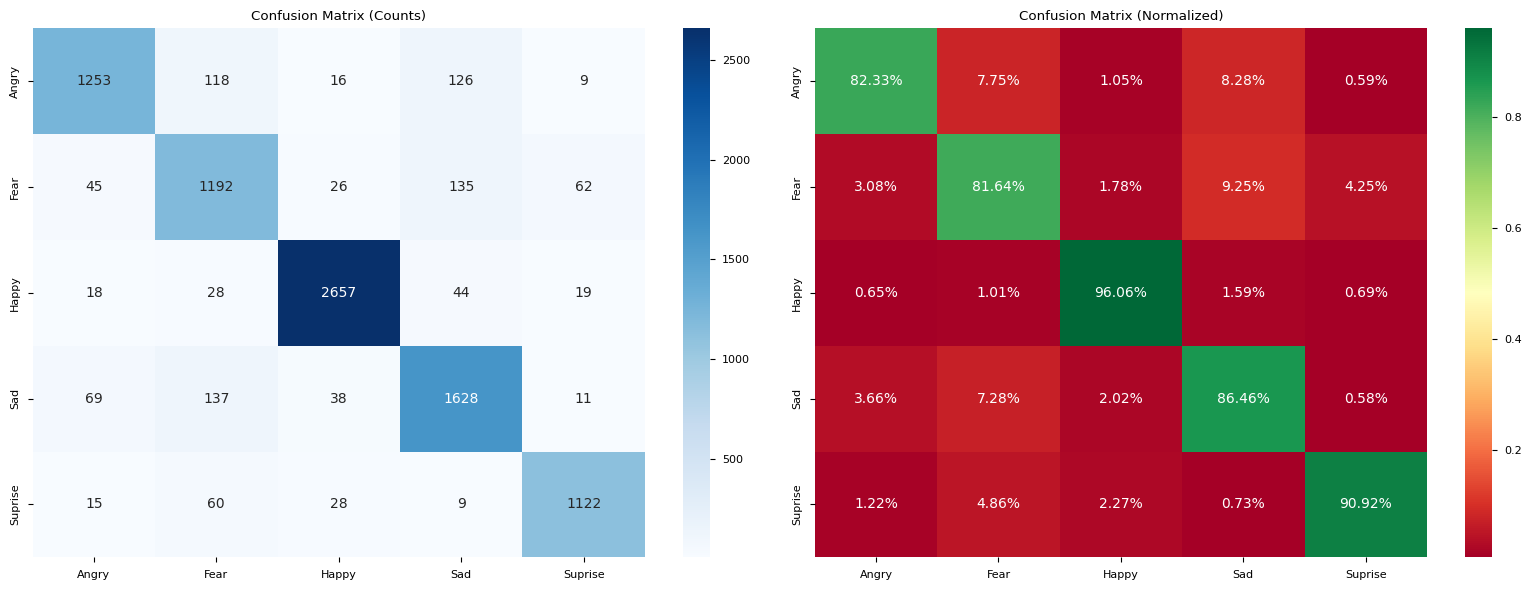


========== PER-CLASS METRICS ==========

   Emotion  Precision    Recall  F1-Score  Support
0    Angry   0.895000  0.823259  0.857632     1522
1     Fear   0.776547  0.816438  0.795993     1460
2    Happy   0.960940  0.960593  0.960767     2766
3      Sad   0.838311  0.864578  0.851242     1883
4  Suprise   0.917416  0.909238  0.913309     1234


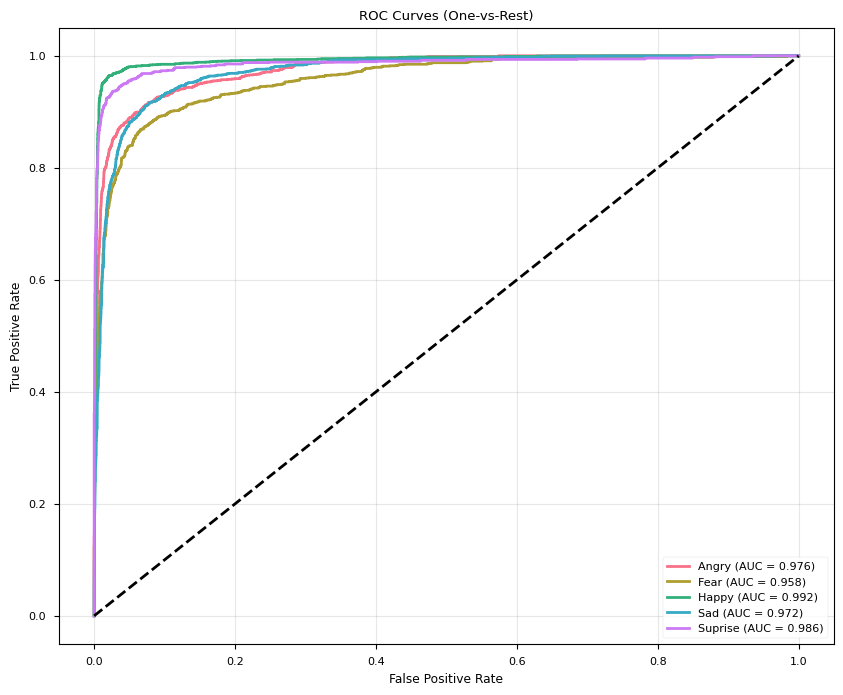


================ EVALUATION COMPLETE ================
[SAVED]
 - classification_report.txt
 - confusion_matrix.png
 - per_class_metrics.csv
 - roc_curves.png


In [8]:
# ===================== FERNet Evaluation (NO Retraining) =====================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
    roc_curve,
    auc
)

from tensorflow.keras.models import load_model
from tensorflow.keras.utils import to_categorical
from itertools import cycle

# ================= CONFIG =================
NUM_CLASSES = 5
CLASS_NAMES = ['Angry', 'Fear', 'Happy', 'Sad', 'Suprise']
DATA_DIR = "/content/processed_data"
MODEL_PATH = "/content/model/fernet_best.keras"   # or fernet_best.h5
RESULTS_DIR = "/content/results_eval"

os.makedirs(RESULTS_DIR, exist_ok=True)
plt.style.use("seaborn-v0_8-paper")
sns.set_palette("husl")

# ================= LOAD DATA =================
print("[INFO] Loading dataset...")
X = np.load(os.path.join(DATA_DIR, "fdataX.npy"))
y = np.load(os.path.join(DATA_DIR, "flabels.npy"))

y_labels = np.argmax(y, axis=1)

# SAME test split as training
_, X_test, _, y_test = train_test_split(
    X, y,
    test_size=0.15,
    random_state=42,
    stratify=y_labels
)

print("[INFO] Test samples:", X_test.shape[0])

# ================= LOAD MODEL =================
print("[INFO] Loading trained model...")
model = load_model(MODEL_PATH, compile=False)
print("[INFO] Model loaded successfully")

# ================= PREDICTION =================
print("[INFO] Running inference...")
y_pred_prob = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test, axis=1)

# ================= CLASSIFICATION REPORT =================
report = classification_report(
    y_true, y_pred,
    target_names=CLASS_NAMES,
    digits=4
)
print("\n========== CLASSIFICATION REPORT ==========\n")
print(report)

with open(os.path.join(RESULTS_DIR, "classification_report.txt"), "w") as f:
    f.write(report)

# ================= CONFUSION MATRIX =================
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES,
            ax=axes[0])
axes[0].set_title("Confusion Matrix (Counts)")

sns.heatmap(cm_norm, annot=True, fmt=".2%",
            cmap="RdYlGn",
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES,
            ax=axes[1])
axes[1].set_title("Confusion Matrix (Normalized)")

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "confusion_matrix.png"), dpi=300)
plt.show()

# ================= PER-CLASS METRICS =================
precision, recall, f1, support = precision_recall_fscore_support(
    y_true, y_pred, labels=range(NUM_CLASSES)
)

metrics_df = pd.DataFrame({
    "Emotion": CLASS_NAMES,
    "Precision": precision,
    "Recall": recall,
    "F1-Score": f1,
    "Support": support
})

metrics_df.to_csv(
    os.path.join(RESULTS_DIR, "per_class_metrics.csv"),
    index=False
)

print("\n========== PER-CLASS METRICS ==========\n")
print(metrics_df)

# ================= ROC CURVES =================
y_true_bin = to_categorical(y_true, NUM_CLASSES)

plt.figure(figsize=(10, 8))
colors = cycle(sns.color_palette("husl", NUM_CLASSES))

for i, color in zip(range(NUM_CLASSES), colors):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(
        fpr, tpr, color=color, lw=2,
        label=f"{CLASS_NAMES[i]} (AUC = {roc_auc:.3f})"
    )

plt.plot([0, 1], [0, 1], "k--", lw=2)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (One-vs-Rest)")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.savefig(os.path.join(RESULTS_DIR, "roc_curves.png"), dpi=300)
plt.show()

# ================= DONE =================
print("\n================ EVALUATION COMPLETE ================")
print("[SAVED]")
print(" - classification_report.txt")
print(" - confusion_matrix.png")
print(" - per_class_metrics.csv")
print(" - roc_curves.png")
print("====================================================")


In [9]:
!zip -r results-eval.zip /content/results_eval/


  adding: content/results_eval/ (stored 0%)
  adding: content/results_eval/classification_report.txt (deflated 56%)
  adding: content/results_eval/per_class_metrics.csv (deflated 36%)
  adding: content/results_eval/roc_curves.png (deflated 20%)
  adding: content/results_eval/confusion_matrix.png (deflated 15%)
